In [1]:
# !pip install pandas
%pip install scikit-learn
%pip install yellowbrick

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached yellowbrick-1.5-py3-none-any.whl.metadata (7.7 kB)
Using cached yellowbrick-1.5-py3-none-any.whl (282 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

# Data splitting
from sklearn.model_selection import train_test_split

# Feature scaling
from sklearn.preprocessing import StandardScaler

# Deep Neural Network (MLP)
from sklearn.neural_network import MLPClassifier

# Evaluation
from sklearn.metrics import accuracy_score

# Visualization (optional but good for marks)
from yellowbrick.classifier import ConfusionMatrix

In [3]:
# Make sure "LetterRecognition.csv" is in same folder

df = pd.read_csv("LetterRecognition.csv")

df.head()

,lettr,x.box,y.box,width,high,onpix,x.bar,y.bar,x2bar,y2bar,xybar,x2ybr,xy2br,x.ege,xegvy,y.ege,yegvx
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


In [4]:
# First column = letter (target)
# Remaining columns = features

X = df.iloc[:, 1:]
y = df.iloc[:, 0]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10
)

In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),   # Deep NN layers
    activation='relu',              # Better than logistic
    max_iter=300,
    random_state=10
)

In [8]:
mlp.fit(X_train, y_train)

,hidden_layer_sizes,"(128, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,300
,shuffle,True
,random_state,10


In [9]:
y_pred = mlp.predict(X_test)

In [10]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.95675


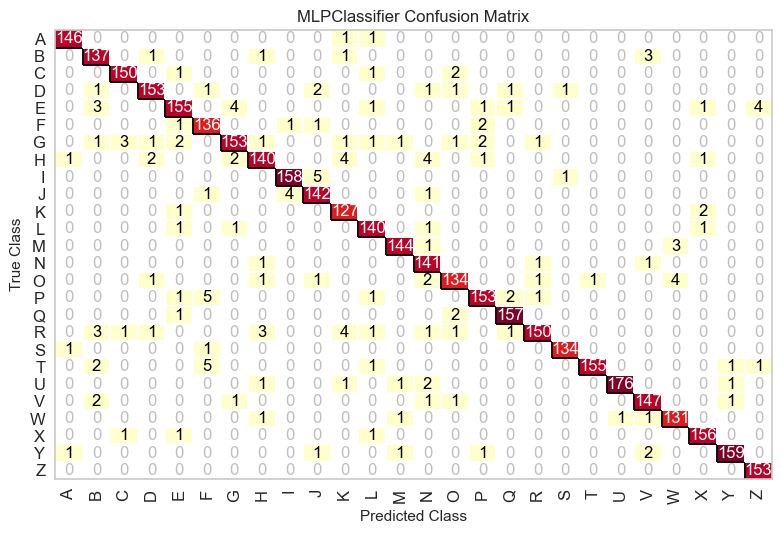

<Axes: title={'center': 'MLPClassifier Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [11]:
cm = ConfusionMatrix(mlp)

cm.fit(X_train, y_train)
cm.score(X_test, y_test)
cm.show()